# ChemAI: Predict the Cure

Цель работы — построить воспроизводимый ML-пайплайн для предсказания трёх биологических показателей молекул:

- `IC50, mM` — концентрация, при которой подавляется 50% активности вируса;
- `CC50, mM` — концентрация, при которой наблюдается токсичность для 50% клеток;
- `SI` — индекс селективности (самостоятельное предсказание, без применения формулы).

В решении используются только признаки из предоставленных `train.csv` и `test.csv`. Все случайные состояния фиксируются через `SEED` / `SEEDS`, чтобы результат можно было воспроизвести.

## Постановка задачи и план решения

Метрика соревнования — средний RMSE по трём таргетам. Поэтому важно контролировать качество не только в среднем, но и отдельно по `IC50`, `CC50` и `SI`: ошибка одного таргета напрямую влияет на итоговый балл.

План работы:

1. загрузить данные и проверить совпадение признаков в train/test;
2. изучить пропуски, распределения таргетов и наличие выбросов;
3. проверить связь `SI` с `IC50`/`CC50`, но не использовать формулу, так как по правилам `SI` должен предсказываться отдельной моделью;
4. протестировать feature engineering;
5. сравнить несколько базовых моделей;
6. подобрать итоговую конфигурацию по кросс-валидации;
7. обучить финальный seed-ансамбль на всех обучающих данных и сохранить `submission.csv`.


## Примечание о формате выполнения

Работа выполнена индивидуально. Я понимаю, что по условиям практики задача предполагает командный формат, поэтому отдельно уделяю внимание воспроизводимости, структуре репозитория, объяснению решений и корректности ML-пайплайна. Cогласен с возможным снижением оценки за несоблюдение этого требования.


![Leaderboard result](leaderboard_1.png)

![Leaderboard result](leaderboard_2.png)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import StratifiedKFold

In [53]:
SEED = 42

# Усреднение по нескольким сидам снижает дисперсию случайного леса (seed-ансамбль).
# Именно это усреднение формирует финальное предсказание, поэтому список сидов фиксируем здесь.
SEEDS = [42, 2024, 2025, 777, 1234]

# Загрузка данных

In [54]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

print(train.shape)
print(test.shape)
print(sample_submission.shape)

display(train.head())
display(test.head())
display(sample_submission.head())

display(train.columns.tolist())
display(test.columns.tolist())


print("\nSAMPLE SUBMISSION")
sample_submission.info()

(751, 214)
(250, 211)
(250, 4)


,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,...,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,...,0,1,0,0,0,0,0,0,0,0
2,2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,...,0,0,0,0,0,0,0,0,0,0
3,3,6.827881,682.788051,100.000000,13.317130,13.317130,0.020658,-4.829339,0.345823,12.400000,...,0,0,1,0,0,0,0,0,0,0
4,4,2.003253,70.001455,34.943894,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,...,0,0,0,0,0,0,0,0,0,0


,index,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,13.761882,13.761882,0.121946,-0.962625,0.770057,30.580645,450.541,432.397,450.070799,...,1,0,0,0,0,0,0,1,0,0
1,1,13.224489,13.224489,0.066132,-1.801871,0.278628,25.687500,448.380,428.220,448.100561,...,0,0,0,0,0,0,0,0,0,0
2,2,6.191528,6.191528,0.445278,0.445278,0.657472,55.384615,179.307,158.139,179.167400,...,0,0,0,0,0,0,0,0,0,0
3,3,14.061236,14.061236,0.054870,-6.660336,0.564307,23.464286,410.289,397.185,410.086525,...,0,0,0,0,0,0,0,0,0,0
4,4,12.790378,12.790378,0.320463,-1.642616,0.696213,22.000000,280.279,268.183,280.073559,...,0,0,0,0,0,0,0,0,0,0


,index,IC50,CC50,SI
0,0,0.723678,0.426328,0.308486
1,1,0.804617,0.643166,0.179750
2,2,0.907425,0.518521,0.298384
3,3,0.563266,0.054770,0.280019
4,4,0.935028,0.616856,0.979752


['index',
 'IC50, mM',
 'CC50, mM',
 'SI',
 'MaxAbsEStateIndex',
 'MaxEStateIndex',
 'MinAbsEStateIndex',
 'MinEStateIndex',
 'qed',
 'SPS',
 'MolWt',
 'HeavyAtomMolWt',
 'ExactMolWt',
 'NumValenceElectrons',
 'NumRadicalElectrons',
 'MaxPartialCharge',
 'MinPartialCharge',
 'MaxAbsPartialCharge',
 'MinAbsPartialCharge',
 'FpDensityMorgan1',
 'FpDensityMorgan2',
 'FpDensityMorgan3',
 'BCUT2D_MWHI',
 'BCUT2D_MWLOW',
 'BCUT2D_CHGHI',
 'BCUT2D_CHGLO',
 'BCUT2D_LOGPHI',
 'BCUT2D_LOGPLOW',
 'BCUT2D_MRHI',
 'BCUT2D_MRLOW',
 'AvgIpc',
 'BalabanJ',
 'BertzCT',
 'Chi0',
 'Chi0n',
 'Chi0v',
 'Chi1',
 'Chi1n',
 'Chi1v',
 'Chi2n',
 'Chi2v',
 'Chi3n',
 'Chi3v',
 'Chi4n',
 'Chi4v',
 'HallKierAlpha',
 'Ipc',
 'Kappa1',
 'Kappa2',
 'Kappa3',
 'LabuteASA',
 'PEOE_VSA1',
 'PEOE_VSA10',
 'PEOE_VSA11',
 'PEOE_VSA12',
 'PEOE_VSA13',
 'PEOE_VSA14',
 'PEOE_VSA2',
 'PEOE_VSA3',
 'PEOE_VSA4',
 'PEOE_VSA5',
 'PEOE_VSA6',
 'PEOE_VSA7',
 'PEOE_VSA8',
 'PEOE_VSA9',
 'SMR_VSA1',
 'SMR_VSA10',
 'SMR_VSA2',
 'SMR_VSA

['index',
 'MaxAbsEStateIndex',
 'MaxEStateIndex',
 'MinAbsEStateIndex',
 'MinEStateIndex',
 'qed',
 'SPS',
 'MolWt',
 'HeavyAtomMolWt',
 'ExactMolWt',
 'NumValenceElectrons',
 'NumRadicalElectrons',
 'MaxPartialCharge',
 'MinPartialCharge',
 'MaxAbsPartialCharge',
 'MinAbsPartialCharge',
 'FpDensityMorgan1',
 'FpDensityMorgan2',
 'FpDensityMorgan3',
 'BCUT2D_MWHI',
 'BCUT2D_MWLOW',
 'BCUT2D_CHGHI',
 'BCUT2D_CHGLO',
 'BCUT2D_LOGPHI',
 'BCUT2D_LOGPLOW',
 'BCUT2D_MRHI',
 'BCUT2D_MRLOW',
 'AvgIpc',
 'BalabanJ',
 'BertzCT',
 'Chi0',
 'Chi0n',
 'Chi0v',
 'Chi1',
 'Chi1n',
 'Chi1v',
 'Chi2n',
 'Chi2v',
 'Chi3n',
 'Chi3v',
 'Chi4n',
 'Chi4v',
 'HallKierAlpha',
 'Ipc',
 'Kappa1',
 'Kappa2',
 'Kappa3',
 'LabuteASA',
 'PEOE_VSA1',
 'PEOE_VSA10',
 'PEOE_VSA11',
 'PEOE_VSA12',
 'PEOE_VSA13',
 'PEOE_VSA14',
 'PEOE_VSA2',
 'PEOE_VSA3',
 'PEOE_VSA4',
 'PEOE_VSA5',
 'PEOE_VSA6',
 'PEOE_VSA7',
 'PEOE_VSA8',
 'PEOE_VSA9',
 'SMR_VSA1',
 'SMR_VSA10',
 'SMR_VSA2',
 'SMR_VSA3',
 'SMR_VSA4',
 'SMR_VSA5',
 'S


SAMPLE SUBMISSION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   index   250 non-null    int64  
 1   IC50    250 non-null    float64
 2   CC50    250 non-null    float64
 3   SI      250 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 7.9 KB


# EDA и feature engineering

## Подготовка признаков и таргетов

Из `train` отделяем три целевые переменные, а в качестве признаков используем только молекулярные дескрипторы, которые есть одновременно в train и test. Столбец `index` не является признаком модели.

In [55]:
TARGET_COLS = ["IC50, mM", "CC50, mM", "SI"]
SUBMISSION_TARGET_COLS = ["IC50", "CC50", "SI"]
ID_COL = "index"

train_features = train.drop(columns=[ID_COL] + TARGET_COLS).columns.tolist()
test_features = test.drop(columns=[ID_COL]).columns.tolist()

print("Train features:", len(train_features))
print("Test features:", len(test_features))

assert train_features == test_features, "Признаки в train и test не совпадают!"

FEATURE_COLS = test_features

X = train[FEATURE_COLS].copy()
y = train[TARGET_COLS].copy()
X_test = test[FEATURE_COLS].copy()

print(X.shape)
print(y.shape)
print(X_test.shape)

Train features: 210
Test features: 210
(751, 210)
(751, 3)
(250, 210)


## Пропуски

Перед моделированием проверяем наличие пропущенных значений.

In [56]:
missing = pd.DataFrame({
    "train_missing": X.isna().sum(),
    "test_missing": X_test.isna().sum()
})

missing = missing[(missing["train_missing"] > 0) | (missing["test_missing"] > 0)]
display(missing.sort_values(["train_missing", "test_missing"], ascending=False))

,train_missing,test_missing
MaxPartialCharge,2,1
MinPartialCharge,2,1
MaxAbsPartialCharge,2,1
MinAbsPartialCharge,2,1
BCUT2D_MWHI,2,1
BCUT2D_MWLOW,2,1
BCUT2D_CHGHI,2,1
BCUT2D_CHGLO,2,1
BCUT2D_LOGPHI,2,1
BCUT2D_LOGPLOW,2,1


В части признаков есть пропуски. Заполняем медианой не заранее на всем датасете, а внутри пайплайна через `SimpleImputer`, чтобы медианы считались только на обучающей части каждого фолда.

## Анализ таргетов

Смотрим описательные статистики и распределения целевых переменных. Это важно, потому что RMSE чувствителен к большим значениям и выбросам.

In [57]:
display(y.describe())

,"IC50, mM","CC50, mM",SI
count,751.000000,751.000000,751.000000
mean,204.544021,577.426098,89.153313
std,370.367937,641.515163,788.882198
min,0.003517,0.700808,0.011489
25%,13.222351,99.998894,1.500000
50%,44.069306,376.580899,4.000000
75%,206.787402,877.508784,17.372463
max,4095.188563,4538.976189,15620.600000


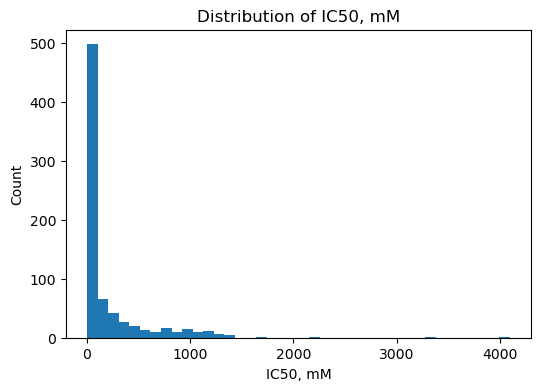

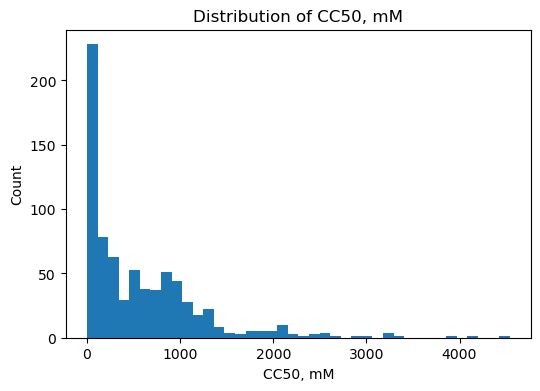

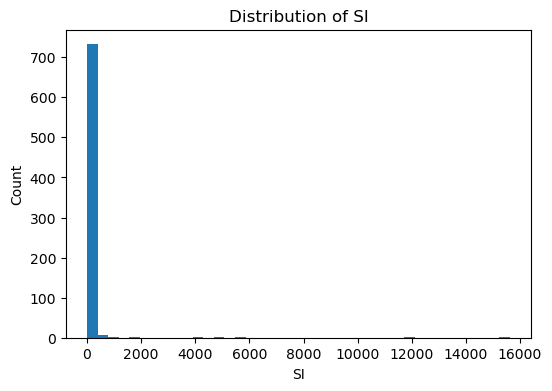

In [58]:
for col in TARGET_COLS:
    plt.figure(figsize=(6, 4))
    plt.hist(y[col], bins=40)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

Гистограммы показывают сильную асимметрию распределений. Дополнительно строим boxplot, чтобы оценить масштаб выбросов.

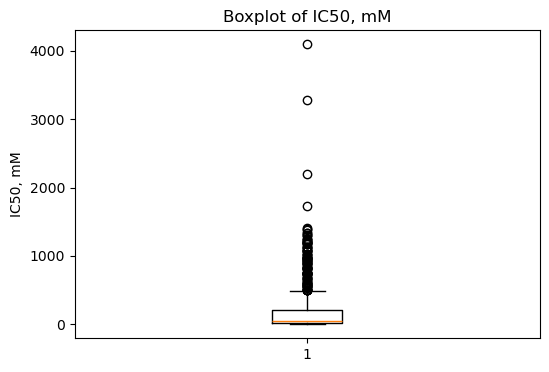

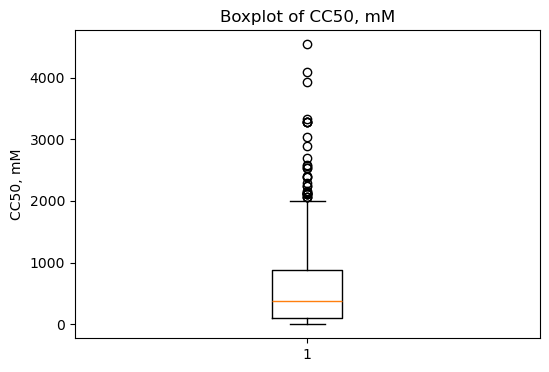

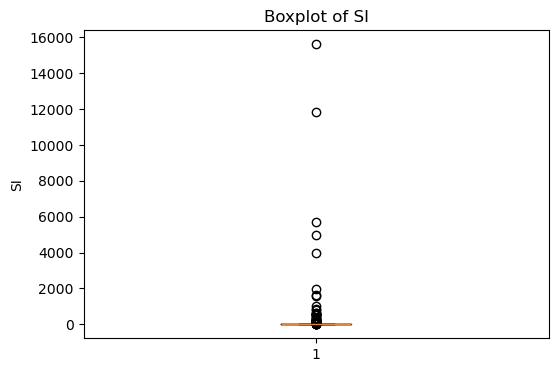

In [59]:
for col in TARGET_COLS:
    plt.figure(figsize=(6, 4))
    plt.boxplot(y[col], vert=True, showfliers=True)
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

Выбросов много, график тоже не показателен. Логарифмируем, что позволяет лучше увидеть основную массу наблюдений и дальше использовать log-модели как один из устойчивых вариантов обучения.

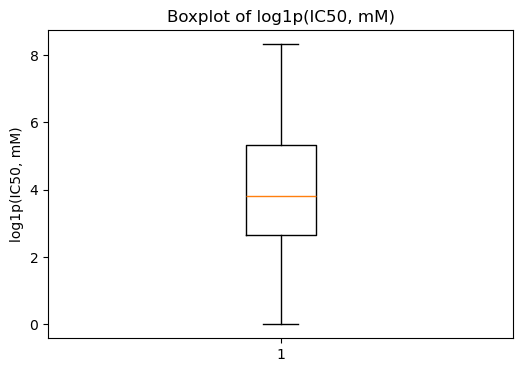

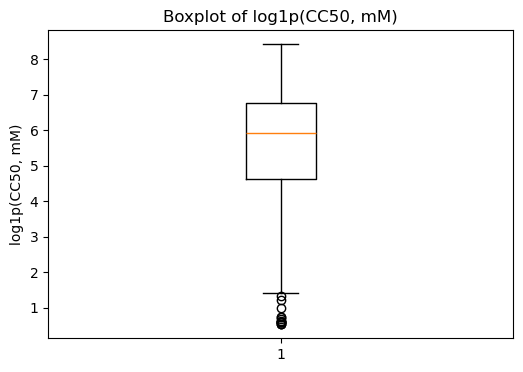

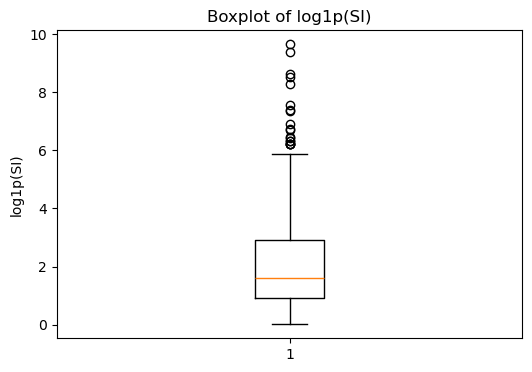

In [60]:
for col in TARGET_COLS:
    plt.figure(figsize=(6, 4))
    plt.boxplot(np.log1p(y[col]), vert=True, showfliers=True)
    plt.title(f"Boxplot of log1p({col})")
    plt.ylabel(f"log1p({col})")
    plt.show()

In [61]:
def count_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    outliers = ((series < lower) | (series > upper)).sum()
    
    return {
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outliers_count": outliers,
        "outliers_share": outliers / len(series)
    }

outlier_info = pd.DataFrame({
    col: count_outliers_iqr(y[col])
    for col in TARGET_COLS
}).T

display(outlier_info)

,q1,q3,iqr,lower_bound,upper_bound,outliers_count,outliers_share
"IC50, mM",13.222351,206.787402,193.565052,-277.125227,497.134980,107.0,0.142477
"CC50, mM",99.998894,877.508784,777.509890,-1066.265941,2043.773619,32.0,0.042610
SI,1.500000,17.372463,15.872463,-22.308694,41.181157,91.0,0.121172


Во всех целевых переменных наблюдаются выбросы. Удалять их не будем, так как высокие значения IC50, CC50 или SI могут быть химически осмысленными. Вместо удаления выбросов используем логарифмическое преобразование target-переменных.

## Проверка связи `SI` с `IC50` и `CC50`

В обучающих данных `SI` численно совпадает с отношением `CC50 / IC50`. Проверка ниже нужна только для понимания структуры данных и контроля интерпретации. В финальном пайплайне `SI` предсказывается отдельной моделью, а не вычисляется из предсказанных `IC50` и `CC50`.

In [62]:
si_from_ratio = train["CC50, mM"] / train["IC50, mM"]

si_check = pd.DataFrame({
    "SI_real": train["SI"],
    "SI_from_CC50_div_IC50": si_from_ratio,
    "abs_diff": np.abs(train["SI"] - si_from_ratio),
    "rel_diff": np.abs(train["SI"] - si_from_ratio) / (np.abs(train["SI"]) + 1e-9)
})

display(si_check.describe())
display(si_check.sort_values("abs_diff", ascending=False).head(10))

,SI_real,SI_from_CC50_div_IC50,abs_diff,rel_diff
count,751.000000,751.000000,7.510000e+02,7.510000e+02
mean,89.153313,89.153313,5.927787e-14,1.899659e-16
std,788.882198,788.882198,8.371712e-13,3.718685e-16
min,0.011489,0.011489,0.000000e+00,0.000000e+00
25%,1.500000,1.500000,0.000000e+00,0.000000e+00
50%,4.000000,4.000000,4.440892e-16,1.477141e-16
75%,17.372463,17.372463,1.776357e-15,2.385428e-16
max,15620.600000,15620.600000,2.000888e-11,7.067718e-15


,SI_real,SI_from_CC50_div_IC50,abs_diff,rel_diff
434,11848.333333,11848.333333,2.000888e-11,1.688751e-15
492,5687.000000,5687.000000,1.000444e-11,1.759177e-15
699,1618.888889,1618.888889,3.637979e-12,2.247207e-15
593,329.750000,329.750000,2.330580e-12,7.067718e-15
254,1952.562500,1952.562500,2.046363e-12,1.048040e-15
663,15620.600000,15620.600000,1.818989e-12,1.164481e-16
91,4001.700000,4001.700000,9.094947e-13,2.272771e-16
400,828.935484,828.935484,7.958079e-13,9.600359e-16
158,170.875000,170.875000,2.273737e-13,1.330643e-15
351,156.266667,156.266667,1.989520e-13,1.273157e-15


В train `SI` практически точно равен `CC50 / IC50`, но условие соревнования требует отдельного предсказания `SI`. Поэтому связь учитывается только как предмет анализа.

# Feature engineering

Признаки уже содержат физико-химические дескрипторы. Попробуем добавить **производные групповые признаки** (диапазоны зарядов/EState, отношения масс и атомов, агрегаты по семействам VSA и `fr_`-групп, плотности Morgan).

Поскольку добавление коррелированных признаков может усилить переобучение, проверяем на кросс-валидации целесообразность таких преобразований: сравниваем baseline и baseline+FE на одной и той же модели. Решение об использовании FE принимается по результату CV.

In [63]:
def add_chem_features(df):
    df = df.copy()
    
    eps = 1e-9
    
    # 1. Зарядовые признаки
    if {"MaxPartialCharge", "MinPartialCharge"}.issubset(df.columns):
        df["charge_range"] = df["MaxPartialCharge"] - df["MinPartialCharge"]
    
    if {"MaxAbsPartialCharge", "MinAbsPartialCharge"}.issubset(df.columns):
        df["abs_charge_range"] = df["MaxAbsPartialCharge"] - df["MinAbsPartialCharge"]
    
    # 2. EState признаки
    if {"MaxEStateIndex", "MinEStateIndex"}.issubset(df.columns):
        df["estate_range"] = df["MaxEStateIndex"] - df["MinEStateIndex"]
    
    if {"MaxAbsEStateIndex", "MinAbsEStateIndex"}.issubset(df.columns):
        df["abs_estate_range"] = df["MaxAbsEStateIndex"] - df["MinAbsEStateIndex"]
    
    # 3. Масса и атомы
    if {"HeavyAtomMolWt", "MolWt"}.issubset(df.columns):
        df["heavy_molwt_ratio"] = df["HeavyAtomMolWt"] / (df["MolWt"] + eps)
    
    if {"ExactMolWt", "MolWt"}.issubset(df.columns):
        df["exact_molwt_diff"] = df["ExactMolWt"] - df["MolWt"]
    
    if {"NumHeteroatoms", "HeavyAtomCount"}.issubset(df.columns):
        df["heteroatom_ratio"] = df["NumHeteroatoms"] / (df["HeavyAtomCount"] + eps)
    
    # 4. Доноры / акцепторы
    if {"NumHAcceptors", "NumHDonors"}.issubset(df.columns):
        df["h_acceptors_donors_sum"] = df["NumHAcceptors"] + df["NumHDonors"]
        df["h_acceptors_donors_ratio"] = df["NumHAcceptors"] / (df["NumHDonors"] + 1)
    
    # 5. Кольца
    if {"NumAromaticRings", "RingCount"}.issubset(df.columns):
        df["aromatic_ring_ratio"] = df["NumAromaticRings"] / (df["RingCount"] + eps)
    
    if {"NumAliphaticRings", "RingCount"}.issubset(df.columns):
        df["aliphatic_ring_ratio"] = df["NumAliphaticRings"] / (df["RingCount"] + eps)
    
    # 6. Функциональные группы fr_*
    fr_cols = [c for c in df.columns if c.startswith("fr_")]
    if len(fr_cols) > 0:
        df["fr_total_count"] = df[fr_cols].sum(axis=1)
        df["fr_nonzero_count"] = (df[fr_cols] > 0).sum(axis=1)
    
    # 7. VSA-группы
    vsa_prefixes = [
        "PEOE_VSA",
        "SMR_VSA",
        "SlogP_VSA",
        "EState_VSA",
        "VSA_EState"
    ]
    
    for prefix in vsa_prefixes:
        cols = [c for c in df.columns if c.startswith(prefix)]
        if len(cols) > 0:
            df[f"{prefix}_sum"] = df[cols].sum(axis=1)
            df[f"{prefix}_mean"] = df[cols].mean(axis=1)
            df[f"{prefix}_std"] = df[cols].std(axis=1)
            df[f"{prefix}_max"] = df[cols].max(axis=1)
    
    # 8. Morgan fingerprints density
    morgan_cols = [c for c in df.columns if c.startswith("FpDensityMorgan")]
    if len(morgan_cols) > 0:
        df["morgan_density_sum"] = df[morgan_cols].sum(axis=1)
        df["morgan_density_mean"] = df[morgan_cols].mean(axis=1)
        df["morgan_density_std"] = df[morgan_cols].std(axis=1)
    
    return df

In [64]:
# Проверка FE на кросс-валидации

def _rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))


def _cv_mean_rmse(X_df, y_df):
    """Средний по таргетам OOF-RMSE: ExtraTrees на log-таргете, 5-fold."""
    kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
    per_target = []
    for t in TARGET_COLS:
        oof = np.zeros(len(X_df))
        for tr_idx, va_idx in kf.split(X_df):
            m = Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("variance", VarianceThreshold()),
                ("model", ExtraTreesRegressor(n_estimators=300, min_samples_leaf=2,
                                              max_features=0.75, random_state=SEED, n_jobs=-1)),
            ])
            m.fit(X_df.iloc[tr_idx], np.log1p(y_df.iloc[tr_idx][t]))
            oof[va_idx] = np.clip(np.expm1(m.predict(X_df.iloc[va_idx])), 0, None)
        per_target.append(_rmse(y_df[t], oof))
    return float(np.mean(per_target))


X_fe = add_chem_features(X)
X_test_fe = add_chem_features(X_test)
assert X_fe.columns.tolist() == X_test_fe.columns.tolist()
print("Признаков: baseline =", X.shape[1], "| с FE =", X_fe.shape[1])

base_cv = _cv_mean_rmse(X, y)
fe_cv = _cv_mean_rmse(X_fe, y)
print(f"\nCV mean-RMSE (ExtraTrees, log1p):")
print(f"  baseline      = {base_cv:.1f}")
print(f"  baseline + FE = {fe_cv:.1f}")


Признаков: baseline = 210 | с FE = 246

CV mean-RMSE (ExtraTrees, log1p):
  baseline      = 535.4
  baseline + FE = 536.8


Добавление групповых признаков увеличило число признаков с 210 до 246, но не улучшило кросс-валидацию на базовой модели: baseline оказался немного лучше, чем baseline+FE. Вероятная причина — небольшой размер обучающей выборки и высокая коррелированность новых агрегатов с уже существующими дескрипторами.

Поэтому в финальной модели используется более консервативный подход: исходные признаки, обработка пропусков внутри пайплайна, удаление константных признаков и при необходимости `SelectKBest` для отбора наиболее полезных признаков под конкретный таргет.

# Моделирование


Функции для вычисления метрики, по которой проверяется результат на Kaggle

In [65]:
def rmse_1d(y_true, y_pred):
    return np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2))


def kaggle_metric(y_true, y_pred):
    """
    Kaggle metric:
    score = (RMSE(IC50) + RMSE(CC50) + RMSE(SI)) / 3
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    scores = []
    for i in range(y_true.shape[1]):
        scores.append(rmse_1d(y_true[:, i], y_pred[:, i]))
    
    return np.mean(scores)


def rmse_by_target(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    return {
        "IC50_RMSE": rmse_1d(y_true[:, 0], y_pred[:, 0]),
        "CC50_RMSE": rmse_1d(y_true[:, 1], y_pred[:, 1]),
        "SI_RMSE": rmse_1d(y_true[:, 2], y_pred[:, 2]),
        "Kaggle_score": kaggle_metric(y_true, y_pred)
    }

Фолды

In [66]:
si_bins = pd.qcut(
    np.log1p(y["SI"]),
    q=5,
    labels=False,
    duplicates="drop"
)

folds = list(
    StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=SEED
    ).split(X, si_bins)
)

## Базовые модели

На первом этапе сравниваем несколько устойчивых моделей для табличных данных: `ExtraTrees`, `RandomForest` и `HistGradientBoosting`. Все модели обучаются отдельно для каждого таргета на `log1p(target)`, так как целевые переменные имеют длинные правые хвосты.


In [67]:
models = {}

models["ExtraTrees"] = lambda: Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("variance", VarianceThreshold()),
    ("model", ExtraTreesRegressor(
        n_estimators=900,
        min_samples_leaf=2,
        max_features=0.75,
        random_state=SEED,
        n_jobs=-1
    ))
])

models["RandomForest"] = lambda: Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("variance", VarianceThreshold()),
    ("model", RandomForestRegressor(
        n_estimators=700,
        min_samples_leaf=2,
        max_features=0.75,
        random_state=SEED,
        n_jobs=-1
    ))
])

models["HistGradientBoosting"] = lambda: Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("variance", VarianceThreshold()),
    ("model", HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.04,
        max_leaf_nodes=15,
        l2_regularization=0.1,
        random_state=SEED
    ))
])

In [68]:
cv_results = []
oof_predictions = {}

for model_name, make_model in models.items():
    print("=" * 70)
    print(model_name)
    print("=" * 70)
    
    oof = np.zeros((len(X), len(TARGET_COLS)))
    
    for target_idx, target_col in enumerate(TARGET_COLS):
        print(f"\nTarget: {target_col}")
        
        for fold, (train_idx, valid_idx) in enumerate(folds, 1):
            X_train_fold = X.iloc[train_idx]
            X_valid_fold = X.iloc[valid_idx]
            
            y_train_fold = y.iloc[train_idx][target_col]
            y_valid_fold = y.iloc[valid_idx][target_col]
            
            model = make_model()
            
            # учим на логарифме, потому что target сильно скошены
            model.fit(X_train_fold, np.log1p(y_train_fold))
            
            pred_log = model.predict(X_valid_fold)
            pred = np.expm1(pred_log)
            pred = np.clip(pred, 0, None)
            
            oof[valid_idx, target_idx] = pred
            
            fold_rmse = rmse_1d(y_valid_fold, pred)
            print(f"Fold {fold}: RMSE = {fold_rmse:.4f}")
    
    metrics = rmse_by_target(y.values, oof)
    
    cv_results.append({
        "model": model_name,
        **metrics
    })
    
    oof_predictions[model_name] = oof
    
    print("\nOOF metrics:")
    print(metrics)
    print()

cv_results = pd.DataFrame(cv_results).sort_values("Kaggle_score")
display(cv_results)

ExtraTrees

Target: IC50, mM


Fold 1: RMSE = 310.3964
Fold 2: RMSE = 329.5939
Fold 3: RMSE = 441.1556
Fold 4: RMSE = 371.6646
Fold 5: RMSE = 320.3755

Target: CC50, mM
Fold 1: RMSE = 534.0846
Fold 2: RMSE = 396.8158
Fold 3: RMSE = 631.2670
Fold 4: RMSE = 432.0402
Fold 5: RMSE = 424.9120

Target: SI
Fold 1: RMSE = 548.2873
Fold 2: RMSE = 199.8714
Fold 3: RMSE = 1337.3827
Fold 4: RMSE = 939.7731
Fold 5: RMSE = 160.2357

OOF metrics:
{'IC50_RMSE': 357.81564999273957, 'CC50_RMSE': 491.6718664847218, 'SI_RMSE': 779.2259388143551, 'Kaggle_score': 542.9044850972722}

RandomForest

Target: IC50, mM
Fold 1: RMSE = 313.1248
Fold 2: RMSE = 324.9830
Fold 3: RMSE = 427.2403
Fold 4: RMSE = 376.0115
Fold 5: RMSE = 324.3571

Target: CC50, mM
Fold 1: RMSE = 554.8183
Fold 2: RMSE = 399.8038
Fold 3: RMSE = 691.8177
Fold 4: RMSE = 445.8913
Fold 5: RMSE = 436.3314

Target: SI
Fold 1: RMSE = 548.1160
Fold 2: RMSE = 199.1742
Fold 3: RMSE = 1339.2071
Fold 4: RMSE = 938.8487
Fold 5: RMSE = 160.8362

OOF metrics:
{'IC50_RMSE': 355.695887225

,model,IC50_RMSE,CC50_RMSE,SI_RMSE,Kaggle_score
0,ExtraTrees,357.815650,491.671866,779.225939,542.904485
1,RandomForest,355.695887,516.866237,779.593928,550.718684
2,HistGradientBoosting,365.967009,510.408915,778.300429,551.558784


In [69]:
best_model_for_target = {
    "IC50": cv_results.sort_values("IC50_RMSE").iloc[0]["model"],
    "CC50": cv_results.sort_values("CC50_RMSE").iloc[0]["model"],
    "SI": cv_results.sort_values("SI_RMSE").iloc[0]["model"],
}

best_model_for_target

{'IC50': 'RandomForest', 'CC50': 'ExtraTrees', 'SI': 'HistGradientBoosting'}

**Промежуточный вывод**

Базовое сравнение показало, что простого выбора одной модели недостаточно: полный OOF-RMSE остаётся высоким, особенно из-за редких экстремальных значений `SI`. При этом разные таргеты ведут себя по-разному, поэтому финальный подход строится покомпонентно:

1. для каждого таргета подбирается своя модель и свои параметры регуляризации;
2. для `IC50` и `CC50` дополнительно сравниваются два режима обучения — `log1p(target)` и сырой target;
3. для `SI` используется отдельная log-модель, без вычисления через `CC50 / IC50`;
4. качество оценивается на кросс-валидации, а не по тестовой выборке.

# Итоговый подход

Финальная модель — это ансамбль отдельных моделей по таргетам. Такой подход выбран, потому что `IC50`, `CC50` и `SI` имеют разные масштабы, разные хвосты распределений и по-разному реагируют на `log1p`-преобразование.

Для подбора параметров используется сетка по:

- типу ансамбля (`RandomForest` / `ExtraTrees`, выбранному на базовом этапе);
- `min_samples_leaf` как контролю переобучения;
- `max_features` как контролю разнообразия деревьев;
- количеству признаков `k` в `SelectKBest`;
- весу сырой компоненты `w_raw` для `IC50` и `CC50`.

Квантильные маски используются только для анализа и выбора более устойчивой конфигурации на train. Они не используют тестовые ответы и не меняют значения таргетов, поэтому не являются data leakage.


In [ ]:
# Автоподбор: регуляризация (leaf, mf), число признаков k и вес сырой компоненты w_raw.
# Тип модели на таргет фиксируем по результатам baseline-сравнения выше.
KIND = {"IC50, mM": "RF", "CC50, mM": "ET", "SI": "RF"}
GRID_LEAF = [2, 4, 6]
GRID_MF   = [0.4, 0.5, 0.6]
GRID_K    = [100, None]                  # None = все признаки
GRID_W    = [0.3, 0.4, 0.5, 0.6, 0.7]    # для SI вес фиксируем 0 (отдельная log-модель)


def grid_model(kind, leaf, mf, k, seed=SEED):
    base = (ExtraTreesRegressor(n_estimators=300, min_samples_leaf=leaf, max_features=mf,
                                random_state=seed, n_jobs=-1) if kind == "ET"
            else RandomForestRegressor(n_estimators=250, min_samples_leaf=leaf, max_features=mf,
                                       random_state=seed, n_jobs=-1))
    steps = [("imputer", SimpleImputer(strategy="median")), ("variance", VarianceThreshold())]
    if k is not None:
        steps.append(("select", SelectKBest(f_regression, k=k)))
    steps.append(("model", base))
    return Pipeline(steps)


# Маски режимов
masks = {}
for q in [0.97, 0.98, 0.99]:
    m = np.ones(len(y), bool)
    for t in TARGET_COLS:
        m &= (y[t].values <= y[t].quantile(q))
    masks[q] = m


def grid_oof(target, leaf, mf, k, mode):
    out = np.zeros(len(X))
    kind = KIND[target]
    for tri, vi in folds:                # те же фолды, что и в baseline
        mdl = grid_model(kind, leaf, mf, k)
        yt = y.iloc[tri][target]
        mdl.fit(X.iloc[tri], np.log1p(yt) if mode == "log" else yt)
        p = mdl.predict(X.iloc[vi])
        out[vi] = np.clip(np.expm1(p) if mode == "log" else p, 0, None)
    return out


def cv_score(target, pred):
    return float(np.mean([rmse_1d(y[target].values[masks[q]], pred[masks[q]]) for q in masks]))


best_config = {}
for t in TARGET_COLS:
    best = None
    for leaf in GRID_LEAF:
        for mf in GRID_MF:
            for k in GRID_K:
                log_pred = grid_oof(t, leaf, mf, k, "log")
                weights = [0.0] if t == "SI" else GRID_W
                raw_pred = None if t == "SI" else grid_oof(t, leaf, mf, k, "raw")
                for w in weights:
                    pred = log_pred if w == 0.0 else w * raw_pred + (1 - w) * log_pred
                    s = cv_score(t, pred)
                    if best is None or s < best[0]:
                        best = (s, {"kind": KIND[t], "leaf": leaf, "mf": mf, "k": k, "w_raw": w})
    best_config[t] = best[1]
    print(f"{t}: CV={best[0]:.2f}  ->  {best[1]}")

print("\nВыбранная конфигурация best_config:")
for t in TARGET_COLS:
    print(f"  {t}: {best_config[t]}")

IC50, mM: CV=253.96  ->  {'kind': 'RF', 'leaf': 6, 'mf': 0.4, 'k': 100, 'w_raw': 0.6}
CC50, mM: CV=389.66  ->  {'kind': 'ET', 'leaf': 4, 'mf': 0.6, 'k': 100, 'w_raw': 0.6}
SI: CV=52.55  ->  {'kind': 'RF', 'leaf': 6, 'mf': 0.5, 'k': None, 'w_raw': 0.0}

Выбранная конфигурация best_config:
  IC50, mM: {'kind': 'RF', 'leaf': 6, 'mf': 0.4, 'k': 100, 'w_raw': 0.6}
  CC50, mM: {'kind': 'ET', 'leaf': 4, 'mf': 0.6, 'k': 100, 'w_raw': 0.6}
  SI: {'kind': 'RF', 'leaf': 6, 'mf': 0.5, 'k': None, 'w_raw': 0.0}


# Финальная модель

Используем `best_config`, найденный автоподбором выше. После выбора конфигурации увеличиваем число деревьев и обучаем несколько моделей с разными `random_state`; затем усредняем их предсказания. Это снижает дисперсию случайных лесов и делает submission стабильнее.

`SI` обучается как отдельный таргет по молекулярным признакам. В финальном коде нет шага `SI = CC50 / IC50`, поэтому подход соответствует условию соревнования: связь между таргетами анализируется, но не используется как формульный post-processing.

In [ ]:
# Конфигурация выбрана автоподбором по сетке в ячейке выше:
CONFIG = best_config


def make_model(cfg, seed):
    if cfg["kind"] == "ET":
        base = ExtraTreesRegressor(n_estimators=600, min_samples_leaf=cfg["leaf"],
                                   max_features=cfg["mf"], random_state=seed, n_jobs=-1)
    else:
        base = RandomForestRegressor(n_estimators=500, min_samples_leaf=cfg["leaf"],
                                     max_features=cfg["mf"], random_state=seed, n_jobs=-1)
    steps = [("imputer", SimpleImputer(strategy="median")), ("variance", VarianceThreshold())]
    if cfg["k"] is not None:
        steps.append(("select", SelectKBest(f_regression, k=cfg["k"])))
    steps.append(("model", base))
    return Pipeline(steps)


def predict_mode(target, mode, X_tr, y_tr, X_pred, seeds):
    """Усредненное по сидам предсказание модели таргета в режиме raw или log."""
    cfg = CONFIG[target]
    y_fit = np.log1p(y_tr) if mode == "log" else y_tr
    preds = []
    for seed in seeds:
        m = make_model(cfg, seed)
        m.fit(X_tr, y_fit)
        p = m.predict(X_pred)
        if mode == "log":
            p = np.expm1(p)
        preds.append(np.clip(p, 0, None))
    return np.mean(preds, axis=0)


def predict_blend(target, X_tr, y_tr, X_pred, seeds):
    """Смесь w_raw*raw + (1-w_raw)*log по конфигурации таргета."""
    w = CONFIG[target]["w_raw"]
    log_part = predict_mode(target, "log", X_tr, y_tr, X_pred, seeds)
    if w == 0.0:
        return log_part
    raw_part = predict_mode(target, "raw", X_tr, y_tr, X_pred, seeds)
    return w * raw_part + (1 - w) * log_part

# 1) Честный OOF на тех же фолдах (1 сид)
# Дополнительно смотрим качество на центральной части train-распределения,
# потому что полный RMSE сильно зависит от редких экстремальных значений.
oof = np.zeros((len(X), len(TARGET_COLS)))
for ti, t in enumerate(TARGET_COLS):
    print(f"OOF: {t}")
    for tri, vi in folds:
        oof[vi, ti] = predict_blend(t, X.iloc[tri], y.iloc[tri][t], X.iloc[vi], seeds=[SEED])

print("\n=== Робастная OOF-оценка по квантилям train-распределения ===")
for q in [0.97, 0.98, 0.99, 1.0]:
    mask = np.ones(len(X), bool)
    for t in TARGET_COLS:
        mask &= (y[t].values <= y[t].quantile(q))
    r = [rmse_1d(y[t].values[mask], oof[mask, i]) for i, t in enumerate(TARGET_COLS)]
    tag = " (весь трейн, с выбросами)" if q == 1.0 else ""
    print(f"  q{q} n={mask.sum():3d}  IC50={r[0]:.1f}  CC50={r[1]:.1f}  SI={r[2]:.1f}  MEAN={np.mean(r):.1f}{tag}")

# 2) Финальное обучение на всех данных (усреднение по SEEDS) и предсказание теста
print("\n=== Финальное обучение на всех данных (усреднение по SEEDS) ===")
test_pred = np.zeros((len(X_test), len(TARGET_COLS)))
for ti, t in enumerate(TARGET_COLS):
    test_pred[:, ti] = predict_blend(t, X, y[t], X_test, seeds=SEEDS)

submission = sample_submission.copy()
for i, c in enumerate(SUBMISSION_TARGET_COLS):
    submission[c] = np.round(test_pred[:, i], 6)

assert submission.shape == sample_submission.shape
assert submission.columns.tolist() == sample_submission.columns.tolist()
assert submission.isna().sum().sum() == 0

submission.to_csv("submission.csv", index=False)
print("\nСохранено: submission.csv")
display(submission.head())
display(submission.describe())

OOF: IC50, mM
OOF: CC50, mM
OOF: SI

=== Честный OOF RMSE по режимам (имитация лидерборда) ===
  q0.97 n=688  IC50=242.2  CC50=370.4  SI=28.9  MEAN=213.8
  q0.98 n=709  IC50=254.8  CC50=385.6  SI=48.0  MEAN=229.4
  q0.99 n=730  IC50=265.6  CC50=414.8  SI=81.2  MEAN=253.9
  q1.0 n=751  IC50=325.6  CC50=453.9  SI=784.7  MEAN=521.4 (весь трейн, с выбросами)

=== Финальное обучение на всех данных (усреднение по SEEDS) ===

Сохранено: submission.csv


,index,IC50,CC50,SI
0,0,149.989748,192.885828,4.817262
1,1,172.103294,390.822494,4.110264
2,2,52.294618,300.648795,6.162535
3,3,207.655891,365.226734,3.606133
4,4,169.596563,271.717275,2.376489


,index,IC50,CC50,SI
count,250.000000,250.000000,250.000000,250.000000
mean,124.500000,181.513010,569.234826,15.149210
std,72.312977,186.133081,486.072429,40.009114
min,0.000000,3.021926,24.988757,1.637765
25%,62.250000,57.233701,240.312415,3.780975
50%,124.500000,110.296946,423.054918,5.780417
75%,186.750000,205.954520,718.525014,12.250143
max,249.000000,964.405503,3258.647314,341.338292


# Финальный вывод

В работе построен воспроизводимый ML-пайплайн для задачи ChemAI: Predict the Cure. Основная сложность оказалась не в пропусках или количестве признаков, а в свойствах целевых переменных: все три таргета имеют длинные правые хвосты, а `SI` содержит особенно сильные выбросы. Из-за этого полный OOF-RMSE на train получается высоким и нестабильным, поэтому при выборе модели дополнительно анализировалось качество на центральной части распределения.

Проверенные идеи:

* заполнение пропусков медианой внутри пайплайна, чтобы не было утечки;
* отказ от удаления выбросов, так как большие значения могут быть химически осмысленными;
* тестирование дополнительных групповых признаков и отказ от них, так как они ухудшили CV;
* сравнение нескольких ансамблевых моделей;
* таргет-специфичный подбор параметров и seed-ансамбль для снижения дисперсии.

Финальное решение использует отдельные модели для `IC50`, `CC50` и `SI`. Для `IC50` и `CC50` применяется смесь log- и raw-предсказаний, потому что log-модель устойчивее на основной массе объектов, а raw-компонента помогает не занижать большие значения. Для `SI` используется отдельная log-модель, так как по правилам соревнования `SI` должен предсказываться самостоятельно.

Финальный файл `submission.csv` был получен запуском последней ячейки ноутбука. Public Kaggle score финального submission: **293.808 RMSE**. Все случайные состояния зафиксированы, внешние данные и ручная подгонка test-предсказаний не использовались.
